# Welcome to Colab!

MAE: 3.52
MSE: 17.26
RMSE: 4.15
R² Score: 0.94

Model Coefficients:
          Feature  Coefficient
0   Hours_Studied    13.021426
1      Attendance     4.156894
2  Previous_Score     7.900622


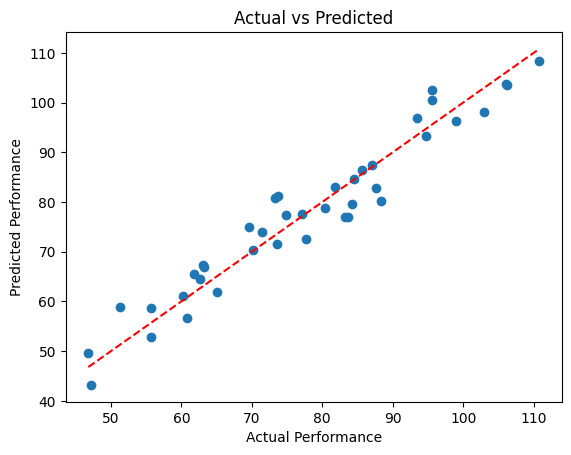

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler

np.random.seed(42)
data_size = 200

df = pd.DataFrame({
    "Hours_Studied": np.random.uniform(1, 10, data_size),
    "Attendance": np.random.uniform(50, 100, data_size),
    "Previous_Score": np.random.uniform(40, 100, data_size)
})


df["Performance"] = (
    5 * df["Hours_Studied"] +
    0.3 * df["Attendance"] +
    0.4 * df["Previous_Score"] +
    np.random.normal(0, 5, data_size)
)


X = df[["Hours_Studied", "Attendance", "Previous_Score"]]
y = df["Performance"]


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


model = LinearRegression()
model.fit(X_train, y_train)


y_pred = model.predict(X_test)


mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

coefficients = pd.DataFrame({
    "Feature": ["Hours_Studied", "Attendance", "Previous_Score"],
    "Coefficient": model.coef_
})

print("\nModel Coefficients:")
print(coefficients)


import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Performance")
plt.ylabel("Predicted Performance")
plt.title("Actual vs Predicted")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()